# Student Placement Prediction System Using Machine Learning

## Objective
The objective of this project is to predict whether a student will get placed based on academic performance, communication skills, internships, projects, and other factors using Machine Learning techniques.

## Dataset Information
This project uses the **College Student Placement Dataset** obtained from Kaggle.

### Dataset Features
- College_ID
- IQ
- Previous Semester Result
- CGPA
- Academic Performance
- Internship Experience
- Extra Curricular Score
- Communication Skills
- Projects Completed
- Placement Status

### Dataset Size
- Total Records: 10,000
- Total Features: 10

## Technologies Used
- NumPy
- Pandas
- Matplotlib
- Scikit-Learn

## Machine Learning Algorithms Used
1. Logistic Regression
2. Random Forest Classifier

## Project Workflow
1. Data Collection from Kaggle
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Data Visualization using Matplotlib
5. Feature Engineering
6. Model Training
7. Model Evaluation
8. Placement Prediction

## Expected Outcome
The model predicts whether a student is likely to be placed based on academic and skill-related attributes and identifies the factors that contribute most to placement success.

Step 1: Import Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

Step 2: Load Dataset

In [28]:
df = pd.read_csv("college_student_placement_dataset.csv")

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


Step 3: Dataset Overview

In [29]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


Step 4: NumPy Analysis

In [30]:
cgpa = np.array(df["CGPA"])

print("Average CGPA:", np.mean(cgpa))
print("Maximum CGPA:", np.max(cgpa))
print("Minimum CGPA:", np.min(cgpa))

Average CGPA: 7.532379
Maximum CGPA: 10.46
Minimum CGPA: 4.54


Step 5: Data Preprocessing

In [31]:
le = LabelEncoder()

df["Internship_Experience"] = le.fit_transform(df["Internship_Experience"])

df["Placement"] = le.fit_transform(df["Placement"])

In [32]:
df = df.drop("College_ID", axis=1)

**Visualizations**

Graph 1: Placement Distribution

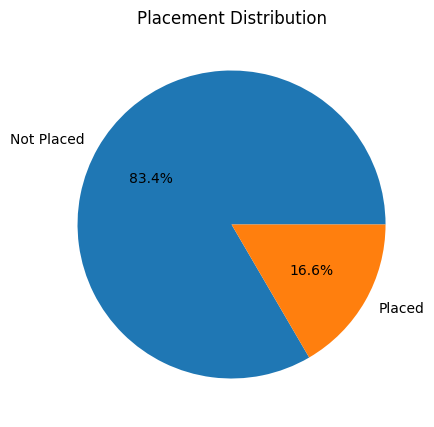

In [33]:
placement_counts = df["Placement"].value_counts()

plt.figure(figsize=(6,5))

plt.pie(
    placement_counts,
    labels=["Not Placed","Placed"],
    autopct="%1.1f%%"
)

plt.title("Placement Distribution")

plt.show()

Graph 2: CGPA vs Placement

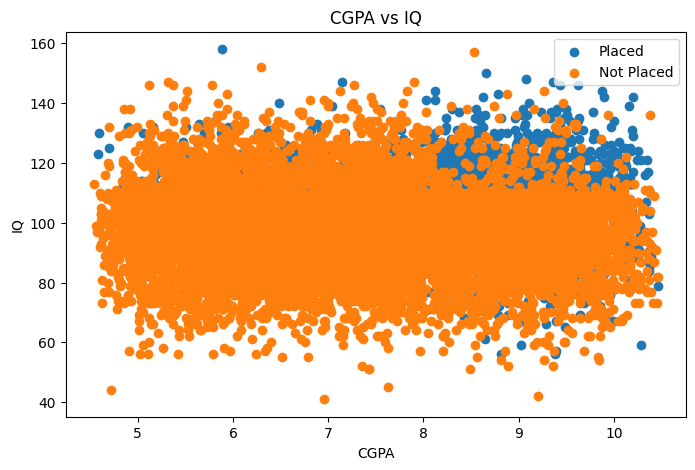

In [34]:
placed = df[df["Placement"] == 1]
not_placed = df[df["Placement"] == 0]

plt.figure(figsize=(8,5))

plt.scatter(
    placed["CGPA"],
    placed["IQ"],
    label="Placed"
)

plt.scatter(
    not_placed["CGPA"],
    not_placed["IQ"],
    label="Not Placed"
)

plt.xlabel("CGPA")
plt.ylabel("IQ")

plt.title("CGPA vs IQ")

plt.legend()

plt.show()

Graph 3: Communication Skills

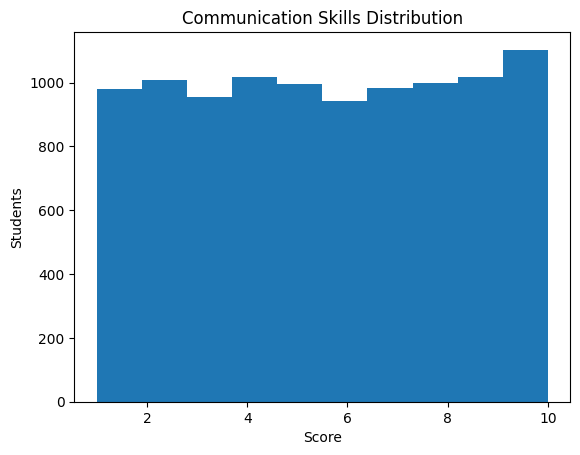

In [35]:
plt.hist(df["Communication_Skills"])

plt.title("Communication Skills Distribution")
plt.xlabel("Score")
plt.ylabel("Students")

plt.show()

Graph 4: Projects Completed

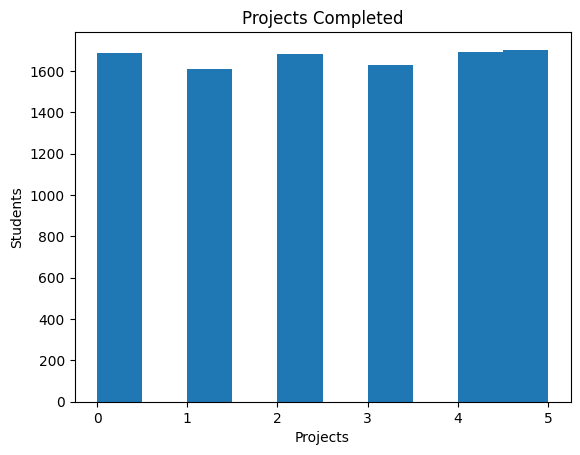

In [36]:
plt.hist(df["Projects_Completed"])

plt.title("Projects Completed")
plt.xlabel("Projects")
plt.ylabel("Students")

plt.show()

Graph 5: Internship Experience

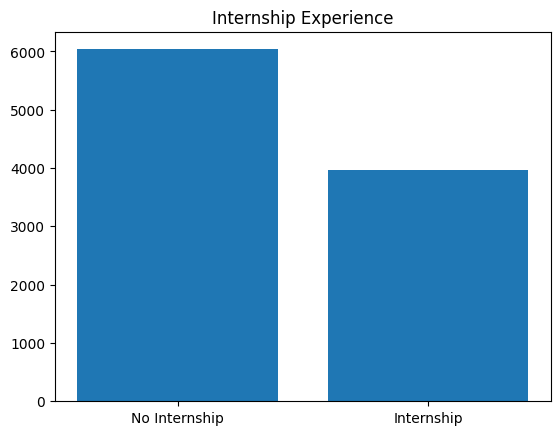

In [37]:
internship = df["Internship_Experience"].value_counts()

plt.bar(
    ["No Internship","Internship"],
    internship
)

plt.title("Internship Experience")

plt.show()

Machine Learning

Features & Target

In [38]:
X = df.drop("Placement", axis=1)

y = df["Placement"]

Train Test Split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Scaling

In [40]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Model 1: Logistic Regression

In [41]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc * 100)

Logistic Regression Accuracy: 90.35


Model 2: Random Forest

In [42]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc * 100)

Random Forest Accuracy: 100.0


Accuracy Comparison

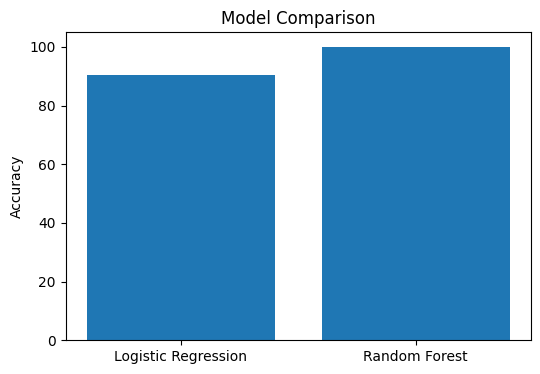

In [43]:
models = [
    "Logistic Regression",
    "Random Forest"
]

scores = [
    lr_acc * 100,
    rf_acc * 100
]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

Feature Importance

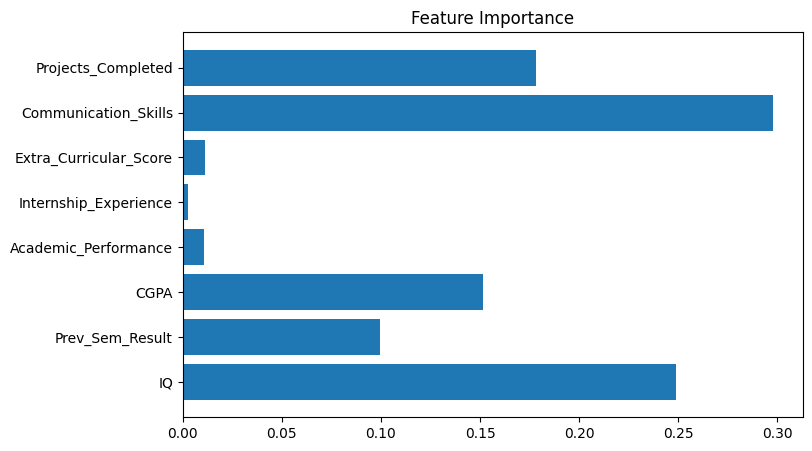

In [44]:
importance = rf.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

plt.barh(features, importance)

plt.title("Feature Importance")

plt.show()

Predict Placement Probability

In [45]:
student = [[
    115,   # IQ
    8.5,   # Prev Sem Result
    8.8,   # CGPA
    9,     # Academic Performance
    1,     # Internship Experience
    8,     # Extra Curricular
    9,     # Communication Skills
    5      # Projects Completed
]]

student = scaler.transform(student)

probability = rf.predict_proba(student)

print("Placement Probability:",
      probability[0][1] * 100)

Placement Probability: 100.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [46]:
student = [[
    15,   # IQ
    5.5,   # Prev Sem Result
    6.8,   # CGPA
    9,     # Academic Performance
    0,     # Internship Experience
    8,     # Extra Curricular
    2,     # Communication Skills
    5      # Projects Completed
]]

student = scaler.transform(student)

probability = rf.predict_proba(student)

print("Placement Probability:",
      probability[0][1] * 100)

Placement Probability: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Student Placement Prediction System Using Machine Learning

Technologies:
- NumPy
- Pandas
- Matplotlib
- Scikit-Learn

Algorithms:
- Logistic Regression
- Random Forest

Objective:
To predict whether a student is likely to be placed based on academic performance, communication skills, internships, projects and other factors.